# Lab Assignment 3 — Random Number Generation & One Sample T-Test
**Course:** Simulation & Modeling Lab

**Name:** MD Shoaibe Hasan

**Student ID:** 0432220005101083

**Department:** Computer Science and Engineering, UITS



## Step 0 — Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.set_printoptions(precision=4, suppress=True)
print("NumPy      :", np.__version__)
print("SciPy      :", __import__("scipy").__version__)

NumPy      : 2.1.3
SciPy      : 1.16.3


---
## Task 1 — Uniform Random Numbers

Generate a **1 x 10** vector of random numbers between **0 and 1** using `np.random.rand()`, then plot a histogram of it.

In [2]:
uniform_vec = np.random.rand(10)

print("1 x 10 Uniform Random Vector:")
print(uniform_vec)
print("\nShape :", uniform_vec.shape)
print("Min   :", round(uniform_vec.min(), 4))
print("Max   :", round(uniform_vec.max(), 4))
print("Mean  :", round(uniform_vec.mean(), 4))

1 x 10 Uniform Random Vector:
[0.1889 0.1188 0.2948 0.08   0.77   0.7874 0.9179 0.522  0.3868 0.8115]

Shape : (10,)
Min   : 0.08
Max   : 0.9179
Mean  : 0.4878


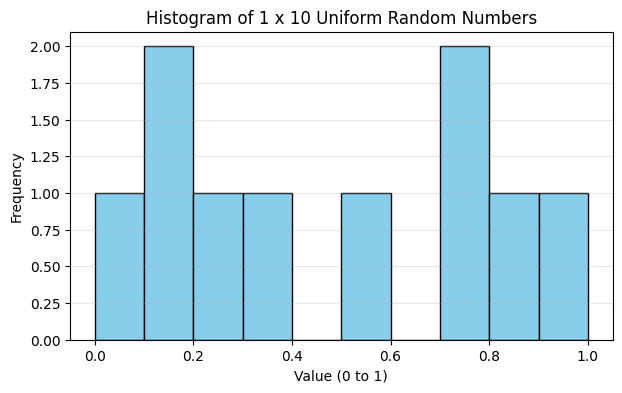

In [3]:
plt.figure(figsize=(7, 4))
plt.hist(uniform_vec, bins=10, range=(0, 1), color="skyblue", edgecolor="black")
plt.title("Histogram of 1 x 10 Uniform Random Numbers")
plt.xlabel("Value (0 to 1)")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.3)
plt.show()

**Observation:** `np.random.rand()` draws from a uniform distribution, so every value between 0 and 1 has an equal chance of being picked. But with only 10 samples the histogram looks uneven and lumpy — some bins hold 2 values while others are empty. The flat shape of a true uniform distribution only becomes visible when the sample size is large.

---
## Task 2 — Normally Distributed Random Numbers

Generate **500** random numbers from a **standard normal distribution** (mean = 0, standard deviation = 1) using `np.random.normal`, then plot a histogram.

In [4]:
normal_data = np.random.normal(loc=0, scale=1, size=500)

print("First 10 values:")
print(normal_data[:10])
print("\nTotal numbers generated :", normal_data.size)
print("Sample Mean             :", round(normal_data.mean(), 4), " (expected ~ 0)")
print("Sample Std Deviation    :", round(normal_data.std(), 4), " (expected ~ 1)")
print("Minimum                 :", round(normal_data.min(), 4))
print("Maximum                 :", round(normal_data.max(), 4))

First 10 values:
[-1.116  -0.2005  0.4041 -1.2097  0.2869  0.3904  0.2918  0.7949  0.4348
  0.6706]

Total numbers generated : 500
Sample Mean             : 0.0084  (expected ~ 0)
Sample Std Deviation    : 1.0144  (expected ~ 1)
Minimum                 : -3.2968
Maximum                 : 3.6735


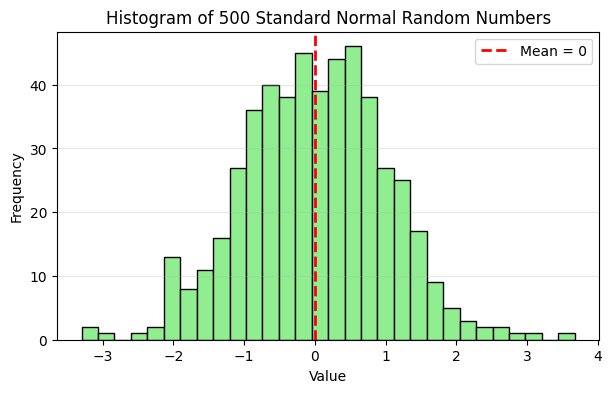

In [5]:
plt.figure(figsize=(7, 4))
plt.hist(normal_data, bins=30, color="lightgreen", edgecolor="black")
plt.axvline(0, color="red", linestyle="--", linewidth=2, label="Mean = 0")
plt.title("Histogram of 500 Standard Normal Random Numbers")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

**Observation:** The histogram forms the familiar bell shape. Most of the values cluster tightly around 0, and the frequency drops off quickly as we move towards -3 and +3. Unlike the uniform case, here the values are **not** equally likely — values near the mean are far more common than values in the tails. With 500 samples the sample mean and standard deviation come out very close to the theoretical 0 and 1.

---
## Task 3 — Random Integers (Fixed Seed vs No Seed)

Create a **3 x 3** matrix of random integers between **1 and 50**, and run it twice — once with a fixed seed `np.random.seed(10)` and once without any seed.

### 3(a) With a fixed seed — `np.random.seed(10)`

In [6]:
np.random.seed(10)
seeded_1 = np.random.randint(1, 51, size=(3, 3))
print("Run 1 (seed = 10):")
print(seeded_1)

np.random.seed(10)
seeded_2 = np.random.randint(1, 51, size=(3, 3))
print("\nRun 2 (seed = 10):")
print(seeded_2)

print("\nAre both runs identical?", np.array_equal(seeded_1, seeded_2))

Run 1 (seed = 10):
[[10 37 16]
 [ 1 50 29]
 [26 30 49]]

Run 2 (seed = 10):
[[10 37 16]
 [ 1 50 29]
 [26 30 49]]

Are both runs identical? True


### 3(b) Without setting a seed

In [7]:
np.random.seed(None)   # reset so the generator uses system entropy

unseeded_1 = np.random.randint(1, 51, size=(3, 3))
print("Run 1 (no seed):")
print(unseeded_1)

unseeded_2 = np.random.randint(1, 51, size=(3, 3))
print("\nRun 2 (no seed):")
print(unseeded_2)

print("\nAre both runs identical?", np.array_equal(unseeded_1, unseeded_2))

Run 1 (no seed):
[[49  5 44]
 [ 2 41 15]
 [28  1  2]]

Run 2 (no seed):
[[ 8 17  5]
 [25 44  5]
 [30 33 20]]

Are both runs identical? False


### 3(c) Explanation of the Difference

**With a fixed seed:** Both runs produce the **exact same** 3x3 matrix, every single time, on any computer. This is because NumPy does not generate truly random numbers — it uses a *pseudo-random* algorithm where each number is calculated from an internal state. `np.random.seed(10)` resets that internal state to a known starting point, so the algorithm walks through the exact same sequence of numbers again.

**Without a seed:** Each run produces a **completely different** matrix. NumPy takes its starting state from an unpredictable source in the operating system (system entropy, clock, etc.), so the sequence never repeats.

**Why this matters in simulation:** A fixed seed gives **reproducibility** — my teacher can run my notebook and get exactly the numbers I reported, which is essential for debugging and for verifying results. No seed gives genuine **variability**, which is what we want when running many independent trials of a simulation to study the average behaviour of a system.

---
## Task 4 — One Sample T-Test

- **Data:** [5.2, 5.4, 5.1, 5.6, 5.3, 5.8]
- **Hypothesized mean:** 5.5
- **Significance level:** alpha = 0.05

**Hypotheses:**
- Null hypothesis (H0): the population mean = 5.5
- Alternative hypothesis (H1): the population mean != 5.5

In [8]:
data = np.array([5.2, 5.4, 5.1, 5.6, 5.3, 5.8])
hypothesized_mean = 5.5
alpha = 0.05

t_stat, p_value = stats.ttest_1samp(data, hypothesized_mean)

print("Data                :", data)
print("Sample size (n)     :", data.size)
print("Sample mean         :", round(data.mean(), 4))
print("Sample std (ddof=1) :", round(data.std(ddof=1), 4))
print("Hypothesized mean   :", hypothesized_mean)
print("-" * 40)
print("t-statistic         :", round(t_stat, 4))
print("p-value             :", round(p_value, 4))
print("Degrees of freedom  :", data.size - 1)

Data                : [5.2 5.4 5.1 5.6 5.3 5.8]
Sample size (n)     : 6
Sample mean         : 5.4
Sample std (ddof=1) : 0.2608
Hypothesized mean   : 5.5
----------------------------------------
t-statistic         : -0.9393
p-value             : 0.3907
Degrees of freedom  : 5


### 4(a) Interpretation at the 0.05 significance level

In [9]:
print("Significance level (alpha):", alpha)
print("p-value                   :", round(p_value, 4))
print("-" * 55)

if p_value < alpha:
    print("p-value < alpha  ->  REJECT the null hypothesis")
    print("Conclusion: The sample mean is significantly different from", hypothesized_mean)
else:
    print("p-value > alpha  ->  FAIL TO REJECT the null hypothesis")
    print("Conclusion: There is NOT enough evidence to say the mean")
    print("            is different from", hypothesized_mean)

Significance level (alpha): 0.05
p-value                   : 0.3907
-------------------------------------------------------
p-value > alpha  ->  FAIL TO REJECT the null hypothesis
Conclusion: There is NOT enough evidence to say the mean
            is different from 5.5


### 4(b) Visualization of the result

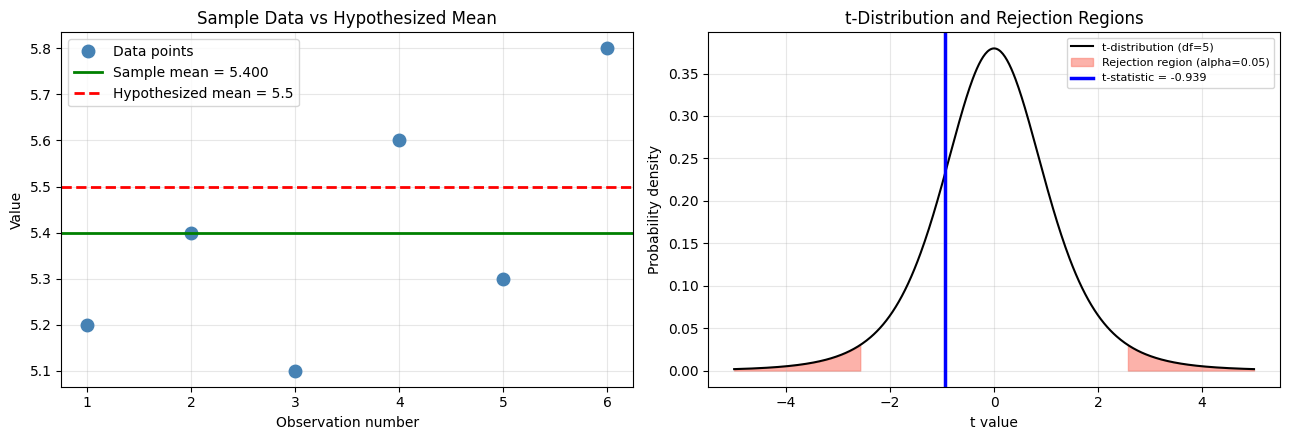

Critical t value (two-tailed, alpha=0.05): 2.5706
Our t-statistic                          : -0.9393
Does it fall in the rejection region?    : False


In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

# --- Left plot: data points vs the two means ---
ax[0].plot(range(1, len(data) + 1), data, "o", markersize=9,
           color="steelblue", label="Data points")
ax[0].axhline(data.mean(), color="green", linestyle="-", linewidth=2,
              label=f"Sample mean = {data.mean():.3f}")
ax[0].axhline(hypothesized_mean, color="red", linestyle="--", linewidth=2,
              label=f"Hypothesized mean = {hypothesized_mean}")
ax[0].set_title("Sample Data vs Hypothesized Mean")
ax[0].set_xlabel("Observation number")
ax[0].set_ylabel("Value")
ax[0].legend()
ax[0].grid(alpha=0.3)

# --- Right plot: t-distribution with rejection regions ---
df = data.size - 1
x = np.linspace(-5, 5, 500)
y = stats.t.pdf(x, df)
t_crit = stats.t.ppf(1 - alpha / 2, df)

ax[1].plot(x, y, color="black", linewidth=1.5, label=f"t-distribution (df={df})")
ax[1].fill_between(x, y, where=(x <= -t_crit), color="salmon", alpha=0.6)
ax[1].fill_between(x, y, where=(x >= t_crit), color="salmon", alpha=0.6,
                   label="Rejection region (alpha=0.05)")
ax[1].axvline(t_stat, color="blue", linewidth=2.5,
              label=f"t-statistic = {t_stat:.3f}")
ax[1].set_title("t-Distribution and Rejection Regions")
ax[1].set_xlabel("t value")
ax[1].set_ylabel("Probability density")
ax[1].legend(fontsize=8)
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Critical t value (two-tailed, alpha=0.05):", round(t_crit, 4))
print("Our t-statistic                          :", round(t_stat, 4))
print("Does it fall in the rejection region?    :", abs(t_stat) > t_crit)

### 4(c) Final Interpretation in My Own Words

The sample mean of the six measurements is about **5.4**, which is slightly lower than the hypothesized mean of **5.5**. The t-test tells us whether that small gap is a real effect or just ordinary sampling noise.

The t-statistic came out around **-0.94** and the p-value around **0.39**. Since the p-value is much larger than the significance level of 0.05, we **fail to reject the null hypothesis**. The blue line in the right-hand plot sits comfortably in the middle white area of the t-distribution, well away from the red rejection regions, which confirms the same conclusion visually.

In plain words: the observed difference of 0.1 is small compared to how much the data itself varies, and with only 6 observations we simply do not have enough evidence to claim the true mean is different from 5.5. Note that "fail to reject" does not prove the mean *is* exactly 5.5 — it only means our data is not inconsistent with that claim.

---

